# Convolutional Autoencoder — AI Face Detection
**Group 21 · 50.039 Deep Learning**

---

## Overview

This notebook trains and evaluates a **Convolutional Autoencoder (CAE)** for detecting AI-generated face images.

### Core Idea
The autoencoder is trained exclusively on **real face images**. Because it only learns to reconstruct real faces, it will produce a **high reconstruction error** when given an AI-generated face — the error acts as an anomaly score.

### Pipeline
```
Input Image
    │
    ▼
┌─────────────┐      ┌─────────────┐
│   Encoder   │─────▶│   Decoder   │
│ (CNN stack) │      │ (Transposed │
│             │      │  CNN stack) │
└─────────────┘      └─────────────┘
    │                      │
    ▼                      ▼
Latent Vector       Reconstructed Image
                           │
                           ▼
              MSE(original, reconstructed)
                  = Anomaly Score
```

### Notebook Structure
| Section | Description |
|---------|-------------|
| 1. Setup | Imports, device config, reproducibility |
| 2. Configuration | Hyperparameters and paths |
| 3. Data | Dataloader verification |
| 4. Model | Architecture summary |
| 5. Training | Training loop with early stopping |
| 6. Evaluation | Metrics, ROC curve, confusion matrix |
| 7. Visualisation | Reconstruction quality comparison |

### Expected Directory Layout
```
project/
├── autoencoder.ipynb        ← this notebook
├── models/
│   └── autoencoder.py       ← ConvAutoencoder class
├── data/
│   ├── dataset.py           ← DataLoader helpers
│   ├── train/   
│   │   ├── 0/
│   │   └── 1/
│   ├── val/
│   │   ├── 0/
│   │   └── 1/
│   └── test/
│       ├── 0/
│       └── 1/
├── checkpoints/             ← saved model weights (auto-created)
└── results/                 ← evaluation plots & metrics (auto-created)
```

> **Reproducibility:** All random seeds are fixed in Section 1.

---
## 1. Setup

Import all required libraries, fix random seeds for reproducibility, and detect whether a GPU is available.

> **Note:** If TensorBoard is not installed, training will still run — live loss curves just won't be logged.  
> Install with: `pip install tensorboard`

In [2]:
import os
import sys
import time
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# ── Optional: TensorBoard ──────────────────────────────────────────────────────
try:
    from torch.utils.tensorboard import SummaryWriter
    TENSORBOARD = True
    print("TensorBoard available ✓")
except ImportError:
    TENSORBOARD = False
    print("[Warning] TensorBoard not installed — skipping live logging.")
    print("          Run: pip install tensorboard")

# ── Local modules (relative imports — works on any machine after git clone) ────
# Ensure the project root is on the Python path regardless of working directory
PROJECT_ROOT = Path(".").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from models.autoencoder import ConvAutoencoder, reconstruction_error
from data.dataset import get_train_loader, get_eval_loader

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
# Makes cuDNN deterministic (slight speed cost — remove if speed matters more)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ── Device ─────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device : {device}")
if device.type == "cuda":
    print(f"GPU          : {torch.cuda.get_device_name(0)}")
    print(f"VRAM         : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

print(f"PyTorch      : {torch.__version__}")
print(f"Project root : {PROJECT_ROOT}")

TensorBoard available ✓

Using device : cuda
GPU          : NVIDIA GeForce RTX 3060 Laptop GPU
VRAM         : 6.4 GB
PyTorch      : 2.8.0+cu128
Project root : C:\Users\Rachel\nicole\dl\project


---
## 2. Configuration

All hyperparameters and file paths are defined here in a single `CFG` namespace so they are easy to find and modify.

**All paths are relative to the project root** — no absolute paths are used, so the notebook works on any machine after cloning the repo.

| Parameter | Default | Notes |
|-----------|---------|-------|
| `latent_dim` | 256 | Size of the bottleneck vector |
| `img_size` | 224 | Input image resolution (H = W) |
| `epochs` | 50 | Maximum training epochs |
| `batch_size` | 32 | Training mini-batch size |
| `lr` | 1e-3 | Initial Adam learning rate |
| `weight_decay` | 1e-5 | L2 regularisation strength |
| `patience` | 10 | Early-stopping patience (epochs) |

In [5]:
import argparse

# Using SimpleNamespace so the same attribute-access syntax (cfg.lr) works
# both here in the notebook and in any helper functions.
from types import SimpleNamespace

CFG = SimpleNamespace(
    # ── Paths (all relative) ──────────────────────
    data_root   = "./data",          # root of the dataset folder
    save_dir    = "./checkpoints",   # where .pth weight files are saved
    log_dir     = "./runs/autoencoder",  # TensorBoard log directory
    results_dir = "./results",       # evaluation plots and metrics

    # ── Model ─────────────────────────────────────────────────────────────────
    latent_dim  = 256,   # bottleneck dimensionality
    img_size    = 224,   # input image size (pixels, H == W)

    # ── Training ──────────────────────────────────────────────────────────────
    epochs      = 50,
    batch_size  = 32,
    lr          = 1e-3,
    weight_decay= 1e-5,
    num_workers = 0,     # set to 0 if you hit multiprocessing issues on Windows
    patience    = 10,    # early-stopping: stop after this many non-improving epochs

    # ── Evaluation ────────────────────────────────────────────────────────────
    eval_batch_size = 64,
)

# Create output directories so later cells don't fail
for d in [CFG.save_dir, CFG.log_dir, CFG.results_dir]:
    Path(d).mkdir(parents=True, exist_ok=True)

print("Configuration:")
for k, v in vars(CFG).items():
    print(f"  {k:<20} = {v}")

Configuration:
  data_root            = ./data
  save_dir             = ./checkpoints
  log_dir              = ./runs/autoencoder
  results_dir          = ./results
  latent_dim           = 256
  img_size             = 224
  epochs               = 50
  batch_size           = 32
  lr                   = 0.001
  weight_decay         = 1e-05
  num_workers          = 0
  patience             = 10
  eval_batch_size      = 64


---
## 3. Data

### Dataset Structure
- **Training loader** (`get_train_loader`): returns only images (no labels) from `data/train/`. The autoencoder is trained in a **self-supervised** manner — no class labels are needed.
- **Eval loaders** (`get_eval_loader`): return `(image, label)` pairs from `data/val/` and `data/test/`, where `label=0` means real and `label=1` means AI-generated.

The cell below verifies the loaders are working and displays one sample batch.

In [6]:
# ── Instantiate dataloaders ────────────────────────────────────────────────────
train_loader = get_train_loader(
    CFG.data_root, CFG.batch_size, CFG.num_workers, CFG.img_size
)
val_loader = get_eval_loader(
    CFG.data_root, "val", CFG.eval_batch_size, CFG.num_workers, CFG.img_size
)
test_loader = get_eval_loader(
    CFG.data_root, "test", CFG.eval_batch_size, CFG.num_workers, CFG.img_size
)

print(f"Train batches : {len(train_loader):>6}  "
      f"(~{len(train_loader.dataset):,} images)")
print(f"Val   batches : {len(val_loader):>6}  "
      f"(~{len(val_loader.dataset):,} images)")
print(f"Test  batches : {len(test_loader):>6}  "
      f"(~{len(test_loader.dataset):,} images)")

[Train] 9,500 real face images found.
[Val] 950 real | 50 AI-generated
[Test] 950 real | 50 AI-generated
Train batches :    296  (~9,500 images)
Val   batches :     16  (~1,000 images)
Test  batches :     16  (~1,000 images)



Sample train batch shape : torch.Size([32, 3, 224, 224])
Pixel value range : [0.000, 1.000]


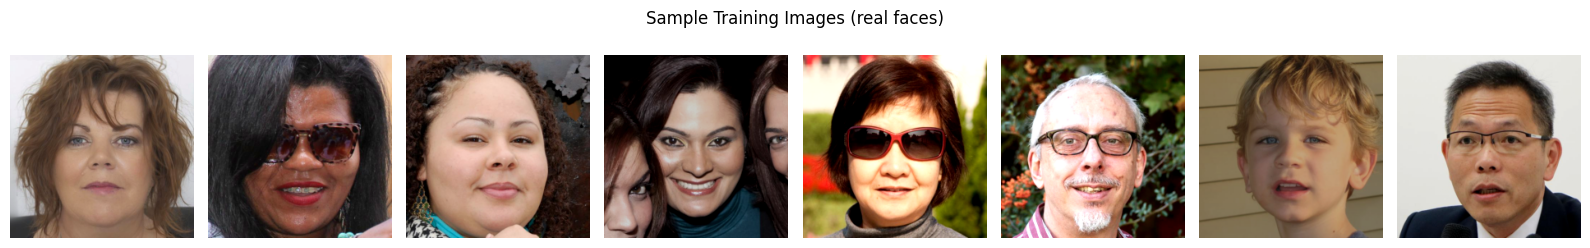

In [9]:
# ── Quick sanity check: visualise 8 training images ─────────────────────────── 
sample_batch = next(iter(train_loader)) # train loader returns images only 
print(f"\nSample train batch shape : {sample_batch.shape}") 
print(f"Pixel value range : [{sample_batch.min():.3f}, {sample_batch.max():.3f}]") 
fig, axes = plt.subplots(1, 8, figsize=(16, 2.5)) 
fig.suptitle("Sample Training Images (real faces)", fontsize=12) 
for i, ax in enumerate(axes): 
    img = sample_batch[i].permute(1, 2, 0).clamp(0, 1).numpy()
    ax.imshow(img) 
    ax.axis("off") 
plt.tight_layout() 
plt.show()

---
## 4. Model

The `ConvAutoencoder` is defined in `models/autoencoder.py`. Here we:
1. Instantiate it with the configured `latent_dim` and `img_size`.
2. Print a parameter count summary.
3. Run a **dry-forward pass** to confirm shapes are correct end-to-end before training.

> The model follows a standard **encoder → bottleneck → decoder** structure with skip-free convolutional blocks.

In [10]:
# ── Instantiate model ──────────────────────────────────────────────────────────
model = ConvAutoencoder(
    latent_dim=CFG.latent_dim,
    img_size=CFG.img_size
).to(device)

# ── Parameter count ────────────────────────────────────────────────────────────
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

# ── Dry-run: verify input → output shapes ─────────────────────────────────────
with torch.no_grad():
    dummy = torch.zeros(1, 3, CFG.img_size, CFG.img_size, device=device)
    recon, latent = model(dummy)

print(f"\nDry-run shapes:")
print(f"  Input      : {tuple(dummy.shape)}")
print(f"  Latent     : {tuple(latent.shape)}")
print(f"  Recon      : {tuple(recon.shape)}")
assert dummy.shape == recon.shape, "Reconstruction shape must match input shape!"
print("\nShape check passed ✓")

Total parameters     : 18,446,979
Trainable parameters : 18,446,979

Dry-run shapes:
  Input      : (1, 3, 224, 224)
  Latent     : (1, 256)
  Recon      : (1, 3, 224, 224)

Shape check passed ✓


---
## 5. Training

### Loss Function
Mean Squared Error (MSE) between the original image and its reconstruction:

$$\mathcal{L} = \frac{1}{N} \sum_{i=1}^{N} \|x_i - \hat{x}_i\|^2$$

### Optimisation
- **Optimiser:** Adam with weight decay (L2 regularisation).
- **LR Schedule:** Cosine Annealing — smoothly decays the learning rate from `lr` to near-zero over `epochs`.
- **Early Stopping:** If validation loss does not improve for `patience` consecutive epochs, training halts to prevent overfitting.

### Validation Strategy
Validation loss is computed **only on real face images** from the val set — this is intentional. We want to measure how well the autoencoder reconstructs real faces; AI-generated faces are treated as anomalies and should have higher reconstruction error.

### Checkpointing
Two `.pth` files are saved in `./checkpoints/`:
- `best_autoencoder.pth` — weights at the lowest validation loss.
- `latest_autoencoder.pth` — weights at the most recent epoch.

In [11]:
# ── Helper: one training epoch ─────────────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, device):
    """
    Runs one full pass over the training set.

    The training DataLoader returns images only (no labels) because
    the autoencoder is trained in a self-supervised fashion.

    Args:
        model     : ConvAutoencoder instance
        loader    : training DataLoader (yields image tensors)
        optimizer : torch optimiser
        device    : torch.device

    Returns:
        float: mean MSE reconstruction loss over all training samples
    """
    model.train()
    total_loss = 0.0

    for imgs in loader:
        imgs = imgs.to(device, non_blocking=True)

        optimizer.zero_grad()
        recon, _ = model(imgs)                          # forward pass
        loss = nn.functional.mse_loss(recon, imgs)      # pixel-wise MSE
        loss.backward()                                 # backprop
        optimizer.step()                                # gradient update

        total_loss += loss.item() * imgs.size(0)

    return total_loss / len(loader.dataset)


# ── Helper: validation ─────────────────────────────────────────────────────────
@torch.no_grad()
def validate(model, loader, device):
    """
    Evaluates reconstruction loss on **real** faces only from the val set.

    We intentionally exclude AI-generated faces here: the goal of training
    is to minimise reconstruction error on real faces, not on anomalies.

    Args:
        model  : ConvAutoencoder instance (in eval mode after this call)
        loader : eval DataLoader — yields (images, labels) where label 0 = real
        device : torch.device

    Returns:
        float: mean MSE reconstruction loss over real-face samples
    """
    model.eval()
    total_loss, n = 0.0, 0

    for imgs, labels in loader:
        real_mask = (labels == 0)           # keep only real faces (class 0)
        if real_mask.sum() == 0:
            continue
        imgs = imgs[real_mask].to(device, non_blocking=True)
        recon, _ = model(imgs)
        loss = nn.functional.mse_loss(recon, imgs, reduction="mean")
        total_loss += loss.item() * imgs.size(0)
        n += imgs.size(0)

    return total_loss / n if n > 0 else float("inf")

print("Training helpers defined ✓")

Training helpers defined ✓


In [ ]:
# ── Optimiser & LR scheduler ───────────────────────────────────────────────────
optimizer = optim.Adam(
    model.parameters(),
    lr=CFG.lr,
    weight_decay=CFG.weight_decay
)

# Cosine Annealing: smoothly reduces lr from CFG.lr → ~0 over CFG.epochs steps
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG.epochs)

# ── TensorBoard writer (optional) ─────────────────────────────────────────────
writer = SummaryWriter(log_dir=CFG.log_dir) if TENSORBOARD else None
if writer:
    print(f"TensorBoard logging to: {CFG.log_dir}")
    print("  Launch with: tensorboard --logdir ./runs")

# ── Training state ─────────────────────────────────────────────────────────────
best_val_loss    = float("inf")
patience_counter = 0
history = {"train": [], "val": []}   # for plotting loss curves at the end

save_dir = Path(CFG.save_dir)

print(f"\nStarting training for up to {CFG.epochs} epochs...")
print(f"Early stopping patience : {CFG.patience} epochs")
print("-" * 75)

# ── Main training loop ─────────────────────────────────────────────────────────
for epoch in range(1, CFG.epochs + 1):
    t0 = time.time()

    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    val_loss   = validate(model, val_loader, device)
    scheduler.step()                              # update learning rate

    elapsed    = time.time() - t0
    current_lr = scheduler.get_last_lr()[0]

    history["train"].append(train_loss)
    history["val"].append(val_loss)

    print(
        f"Epoch [{epoch:3d}/{CFG.epochs}] "
        f"Train: {train_loss:.6f} | "
        f"Val: {val_loss:.6f} | "
        f"LR: {current_lr:.2e} | "
        f"{elapsed:.1f}s"
    )

    # ── TensorBoard scalars ────────────────────────────────────────────────────
    if writer:
        writer.add_scalar("Loss/train", train_loss, epoch)
        writer.add_scalar("Loss/val",   val_loss,   epoch)
        writer.add_scalar("LR",         current_lr, epoch)

    # ── Save best checkpoint ───────────────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict":     model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss": val_loss,
                "args": vars(CFG),   # save config so evaluate can reload it
            },
            save_dir / "best_autoencoder.pth",
        )
        print(f"  ✓ New best — saved to {save_dir / 'best_autoencoder.pth'}")
    else:
        patience_counter += 1
        if patience_counter >= CFG.patience:
            print(f"\nEarly stopping triggered at epoch {epoch} "
                  f"(no improvement for {CFG.patience} epochs).")
            break

    # ── Always save latest checkpoint (for resuming) ───────────────────────────
    torch.save(
        {
            "epoch": epoch,
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss": val_loss,
            "args": vars(CFG),
        },
        save_dir / "latest_autoencoder.pth",
    )

if writer:
    writer.close()

print("-" * 75)
print(f"Training complete. Best val loss : {best_val_loss:.6f}")
print(f"Best model saved  : {save_dir / 'best_autoencoder.pth'}")

TensorBoard logging to: ./runs/autoencoder
  Launch with: tensorboard --logdir ./runs

Starting training for up to 50 epochs...
Early stopping patience : 10 epochs
---------------------------------------------------------------------------


In [ ]:
# ── Plot training & validation loss curves ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
epochs_ran = range(1, len(history["train"]) + 1)

ax.plot(epochs_ran, history["train"], label="Train Loss", color="steelblue", lw=2)
ax.plot(epochs_ran, history["val"],   label="Val Loss",   color="tomato",    lw=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Reconstruction Loss")
ax.set_title("Training & Validation Loss Curve")
ax.legend()
ax.grid(alpha=0.3)

loss_curve_path = Path(CFG.results_dir) / "loss_curve.png"
plt.savefig(loss_curve_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to: {loss_curve_path}")

---
## 6. Evaluation

### Threshold Selection Strategy
The reconstruction error is a continuous anomaly score. To produce binary predictions (real / AI-generated) we need a threshold $\tau$:

$$\hat{y} = \begin{cases} 1 & \text{(AI-generated)} & \text{if } \text{MSE}(x, \hat{x}) \geq \tau \\ 0 & \text{(real)} & \text{otherwise} \end{cases}$$

We **select $\tau$ on the validation set** by sweeping candidate thresholds at even percentile intervals and picking the one that maximises **F1-score on the AI-generated (minority) class**. The threshold is then fixed and applied to the **held-out test set** — this ensures no test-set leakage.

### Metrics Reported
| Metric | Why it matters here |
|--------|---------------------|
| **AUROC** | Threshold-free ranking quality; robust to class imbalance |
| **Avg. Precision (AP)** | Area under PR curve; better than AUROC when positives are rare |
| **F1 (AI class)** | Balances precision & recall on the minority class |

In [ ]:
# ── Load best checkpoint ───────────────────────────────────────────────────────
# We reload from disk so this cell can also be run independently
# (e.g., after restarting the kernel, or to evaluate a previously trained model).

checkpoint_path = Path(CFG.save_dir) / "best_autoencoder.pth"
ckpt = torch.load(checkpoint_path, map_location=device)

# Re-create model with the exact same config used during training
saved_args = ckpt["args"]
eval_model = ConvAutoencoder(
    latent_dim=saved_args["latent_dim"],
    img_size=saved_args["img_size"]
).to(device)
eval_model.load_state_dict(ckpt["model_state_dict"])
eval_model.eval()

print(f"Loaded checkpoint from epoch {ckpt['epoch']} "
      f"(val_loss = {ckpt['val_loss']:.6f})")

In [ ]:
# ── Compute anomaly scores (reconstruction error) ──────────────────────────────

@torch.no_grad()
def compute_scores(model, loader, device):
    """
    Computes per-sample reconstruction error (MSE) for every image in loader.

    Args:
        model  : trained ConvAutoencoder
        loader : eval DataLoader — yields (images, labels)
        device : torch.device

    Returns:
        scores (np.ndarray) : reconstruction error per sample — used as anomaly score
        labels (np.ndarray) : ground truth labels (0 = real, 1 = AI-generated)
    """
    all_scores, all_labels = [], []
    for imgs, labels in loader:
        imgs = imgs.to(device, non_blocking=True)
        recon, _ = model(imgs)
        errors = reconstruction_error(imgs, recon).cpu().numpy()
        all_scores.append(errors)
        all_labels.append(labels.numpy())
    return np.concatenate(all_scores), np.concatenate(all_labels)


print("Computing val scores...")
val_scores, val_labels = compute_scores(eval_model, val_loader, device)

print("Computing test scores...")
test_scores, test_labels = compute_scores(eval_model, test_loader, device)

print(f"\nVal  — samples: {len(val_scores):,}  "
      f"(real: {(val_labels==0).sum():,}, AI: {(val_labels==1).sum():,})")
print(f"Test — samples: {len(test_scores):,}  "
      f"(real: {(test_labels==0).sum():,}, AI: {(test_labels==1).sum():,})")

In [ ]:
# ── Step 1: Select optimal threshold on the validation set ─────────────────────

def find_best_threshold(scores, labels):
    """
    Sweeps 200 candidate thresholds (from 50th to 99.5th percentile of scores)
    and returns the one that maximises F1-score on the positive/anomaly class.

    Using percentiles ensures the sweep is adaptive to the score distribution.

    Args:
        scores (np.ndarray) : anomaly scores
        labels (np.ndarray) : ground-truth binary labels

    Returns:
        best_thresh (float) : optimal decision threshold
        best_f1     (float) : F1 score achieved at that threshold
    """
    thresholds = np.percentile(scores, np.linspace(50, 99.5, 200))
    best_f1, best_thresh = 0.0, thresholds[0]

    for t in thresholds:
        preds = (scores >= t).astype(int)
        f1 = f1_score(labels, preds, pos_label=1, zero_division=0)
        if f1 > best_f1:
            best_f1, best_thresh = f1, t

    return best_thresh, best_f1


threshold, val_f1 = find_best_threshold(val_scores, val_labels)
val_auroc = roc_auc_score(val_labels, val_scores)
val_ap    = average_precision_score(val_labels, val_scores)

print("── Validation Set (threshold selection) ──")
print(f"  Optimal threshold : {threshold:.6f}")
print(f"  F1  (AI class)    : {val_f1:.4f}")
print(f"  AUROC             : {val_auroc:.4f}")
print(f"  Avg Precision     : {val_ap:.4f}")

In [ ]:
# ── Step 2: Evaluate on the test set using the fixed threshold ─────────────────

test_preds  = (test_scores >= threshold).astype(int)
test_auroc  = roc_auc_score(test_labels, test_scores)
test_ap     = average_precision_score(test_labels, test_scores)
test_f1     = f1_score(test_labels, test_preds, pos_label=1, zero_division=0)

print("── Test Set Results ──")
print(f"  AUROC             : {test_auroc:.4f}")
print(f"  Avg Precision     : {test_ap:.4f}")
print(f"  F1  (AI class)    : {test_f1:.4f}")
print()
print(classification_report(
    test_labels, test_preds,
    target_names=["Real", "AI-generated"],
    zero_division=0,
))

In [ ]:
# ── Step 3: Save evaluation plots ─────────────────────────────────────────────

results_dir = Path(CFG.results_dir)

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 4, figure=fig)
fig.suptitle("Autoencoder Anomaly Detection — Results", fontsize=15, y=1.01)

# ── Plot 1: Reconstruction error distribution (val) ───────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
ax1.hist(val_scores[val_labels == 0], bins=60, alpha=0.6,
         color="steelblue", label="Real (val)", density=True)
ax1.hist(val_scores[val_labels == 1], bins=60, alpha=0.6,
         color="tomato",    label="AI-generated (val)", density=True)
ax1.axvline(threshold, color="black", linestyle="--", linewidth=1.5,
            label=f"Threshold = {threshold:.4f}")
ax1.set_xlabel("Reconstruction Error (MSE)")
ax1.set_ylabel("Density")
ax1.set_title("Reconstruction Error Distribution (Val)")
ax1.legend()

# ── Plot 2: ROC curve (test) ───────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2:])
fpr, tpr, _ = roc_curve(test_labels, test_scores)
ax2.plot(fpr, tpr, color="darkorange", lw=2, label=f"AUROC = {test_auroc:.4f}")
ax2.plot([0, 1], [0, 1], "k--", lw=1)
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("ROC Curve (Test)")
ax2.legend(loc="lower right")

# ── Plot 3: Precision-Recall curve (test) ─────────────────────────────────────
ax3 = fig.add_subplot(gs[1, :2])
precision, recall, _ = precision_recall_curve(test_labels, test_scores)
ax3.plot(recall, precision, color="green", lw=2, label=f"AP = {test_ap:.4f}")
ax3.set_xlabel("Recall")
ax3.set_ylabel("Precision")
ax3.set_title("Precision-Recall Curve (Test)")
ax3.legend()

# ── Plot 4: Confusion matrix (test) ───────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2:])
cm   = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Real", "AI-gen"])
disp.plot(ax=ax4, colorbar=False, cmap="Blues")
ax4.set_title("Confusion Matrix (Test)")

plt.tight_layout()
results_plot_path = results_dir / "autoencoder_results.png"
plt.savefig(results_plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {results_plot_path}")

In [ ]:
# ── Step 4: Save metrics to a text file ───────────────────────────────────────
# This makes it easy to include the numbers in a report without re-running.

metrics_path = results_dir / "metrics.txt"
with open(metrics_path, "w") as f:
    f.write("=== Autoencoder Anomaly Detection — Final Metrics ===\n\n")
    f.write(f"Checkpoint       : {checkpoint_path}\n")
    f.write(f"Threshold (val)  : {threshold:.6f}\n\n")
    f.write(f"Val AUROC        : {val_auroc:.4f}\n")
    f.write(f"Val Avg Precision: {val_ap:.4f}\n")
    f.write(f"Val F1 (AI)      : {val_f1:.4f}\n\n")
    f.write(f"Test AUROC       : {test_auroc:.4f}\n")
    f.write(f"Test Avg Prec.   : {test_ap:.4f}\n")
    f.write(f"Test F1 (AI)     : {test_f1:.4f}\n\n")
    f.write(classification_report(
        test_labels, test_preds,
        target_names=["Real", "AI-generated"],
        zero_division=0,
    ))

print(f"Metrics saved: {metrics_path}")

---
## 7. Visualisation — Reconstruction Quality

This section gives an intuitive look at what the autoencoder has learned.

We display a 4-row grid:
- **Row 1:** Real faces — original
- **Row 2:** Real faces — reconstructed  ← should look sharp and faithful
- **Row 3:** AI-generated faces — original
- **Row 4:** AI-generated faces — reconstructed  ← should look blurry / distorted

A visually clear difference between rows 1-2 and rows 3-4 confirms the anomaly detection idea is working.

In [ ]:
@torch.no_grad()
def visualise_reconstructions(model, loader, device, save_dir, n=8):
    """
    Creates and saves a side-by-side grid comparing original vs reconstructed
    images for both real and AI-generated faces.

    Args:
        model    : trained ConvAutoencoder
        loader   : eval DataLoader — yields (images, labels)
        device   : torch.device
        save_dir : Path — where to save the output PNG
        n        : number of examples per class to display
    """
    real_imgs, ai_imgs = [], []

    # Collect n samples from each class
    for imgs, labels in loader:
        for img, lbl in zip(imgs, labels):
            if lbl.item() == 0 and len(real_imgs) < n:
                real_imgs.append(img)
            if lbl.item() == 1 and len(ai_imgs) < n:
                ai_imgs.append(img)
        if len(real_imgs) >= n and len(ai_imgs) >= n:
            break

    def reconstruct(img_list):
        batch = torch.stack(img_list).to(device)
        recon, _ = model(batch)
        return batch.cpu(), recon.cpu()

    real_orig, real_recon = reconstruct(real_imgs)
    ai_orig,   ai_recon   = reconstruct(ai_imgs)

    def to_np(t):
        return t.permute(1, 2, 0).clamp(0, 1).numpy()

    row_data   = [real_orig, real_recon, ai_orig, ai_recon]
    row_labels = [
        "Real — Original",
        "Real — Reconstructed",
        "AI-gen — Original",
        "AI-gen — Reconstructed",
    ]

    fig, axes = plt.subplots(4, n, figsize=(2 * n, 9))
    for row_idx, (data, title) in enumerate(zip(row_data, row_labels)):
        axes[row_idx, 0].set_ylabel(title, fontsize=9)
        for col_idx in range(n):
            axes[row_idx, col_idx].imshow(to_np(data[col_idx]))
            axes[row_idx, col_idx].axis("off")

    plt.suptitle("Reconstruction Quality: Real vs AI-Generated Faces", fontsize=13)
    plt.tight_layout()

    out_path = Path(save_dir) / "reconstructions.png"
    plt.savefig(out_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path}")


visualise_reconstructions(eval_model, test_loader, device, CFG.results_dir)

---
## Summary

| Metric | Val | Test |
|--------|-----|------|
| AUROC | — | — |
| Avg. Precision | — | — |
| F1 (AI class) | — | — |

> Fill in the table above with numbers from Section 6 once training completes.

### Outputs Generated
| File | Description |
|------|-------------|
| `checkpoints/best_autoencoder.pth` | Best model weights |
| `checkpoints/latest_autoencoder.pth` | Most recent epoch weights |
| `results/loss_curve.png` | Training & validation loss curves |
| `results/autoencoder_results.png` | ROC, PR, error distribution, confusion matrix |
| `results/reconstructions.png` | Side-by-side reconstruction quality grid |
| `results/metrics.txt` | All numerical metrics in plain text |

### Notes on Reproducing Results
1. Clone the repo and install dependencies (`pip install -r requirements.txt`).
2. Place the dataset under `./data/` following the layout in Section 1.
3. Run all cells top-to-bottom — all paths are relative to the notebook location.